# Recommending Restaurants based on User Moods

### Our Product is simple. User has to tell us his/her mood, we'll recommend him/her a restaurant according to the mood. The moods are stress, laziness, happy, depression, sick, cold weather, hunger, etc. The model works well for age range 15-30 due to the dataset.

### About the Dataset
We are using two datasets. First is Zomato Restaurants Dataset and Second is Food Choices of College Students Dataset.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

from collections import Counter
from nltk.corpus import stopwords

from nltk.stem import WordNetLemmatizer



## Zomato Restaurants Dataset Analysis (in New Delhi)

In [ ]:
res_data = pd.read_csv('zomato.csv', encoding='latin-1')
countryCode_toName = {
    1: "India",
    14: "Australia",
    30: "Brazil",
    37: "Canada",
    94: "Indonesia",
    148: "New Zealand",
    162: "Phillipines",
    166: "Qatar",
    184: "Singapore",
    189: "South Africa",
    191: "Sri Lanka",
    208: "Turkey",
    214: "UAE",
    215: "United Kingdom",
    216: "United States",
}
res_data['Country'] = res_data['Country Code'].apply(lambda x: countryCode_toName[x])

In [ ]:
res_data = res_data.loc[(res_data['Country Code'] == 1) & (res_data['City'] == 'New Delhi'), :]
res_data = res_data.loc[res_data['Longitude'] != 0, :]
res_data = res_data.loc[res_data['Latitude'] != 0, :]
res_data = res_data.loc[res_data['Latitude'] < 29] # clearing out invalid outlier
res_data = res_data.loc[res_data['Rating text'] != 'Not rated']
res_data['Cuisines'] = res_data['Cuisines'].astype(str)
res_data['fusion_num'] = res_data['Cuisines'].apply(lambda x: len(x.split(',')))
res_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3975 entries, 2561 to 8009
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         3975 non-null   int64  
 1   Restaurant Name       3975 non-null   object 
 2   Country Code          3975 non-null   int64  
 3   City                  3975 non-null   object 
 4   Address               3975 non-null   object 
 5   Locality              3975 non-null   object 
 6   Locality Verbose      3975 non-null   object 
 7   Longitude             3975 non-null   float64
 8   Latitude              3975 non-null   float64
 9   Cuisines              3975 non-null   object 
 10  Average Cost for two  3975 non-null   int64  
 11  Currency              3975 non-null   object 
 12  Has Table booking     3975 non-null   object 
 13  Has Online delivery   3975 non-null   object 
 14  Is delivering now     3975 non-null   object 
 15  Switch to order menu  3

### What are the most famous cuisines in New Delhi?

/tmp/ipykernel_8129/3805284646.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_cnt.rename(columns = {0:'cnt'}, inplace = True)
/tmp/ipykernel_8129/3805284646.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = tmp_cnt.index, y = 'cnt', data = tmp_cnt, ax = ax, palette = sns.color_palette('Blues_d', 10))
/tmp/ipykernel_8129/3805284646.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(res_data['fusion_num'], ax=ax, palette = sns.color_palette('Blues_d', res_data.fusion_num.nunique()))
/tmp

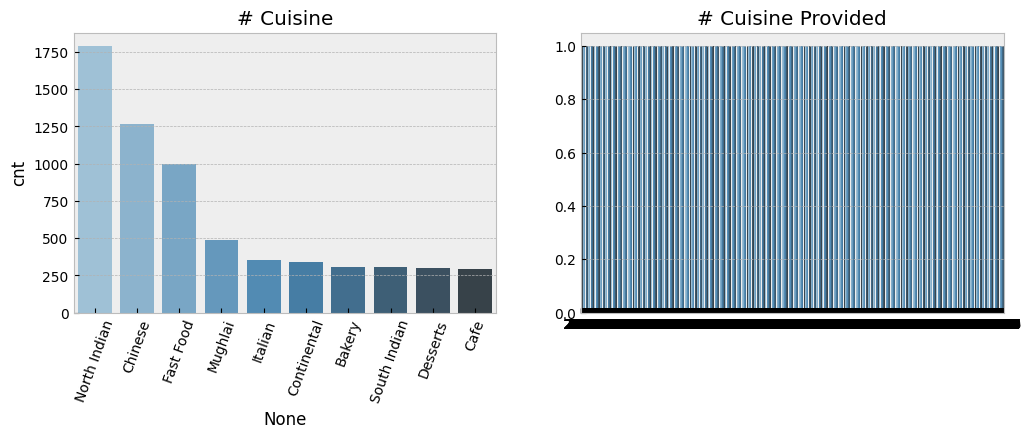

# Unique Cuisine:  78


In [ ]:
lst_cuisine = set()
Cnt_cuisine = Counter()
for cu_lst in res_data['Cuisines']:
    cu_lst = cu_lst.split(',')
    lst_cuisine.update([cu.strip() for cu in cu_lst])
    for cu in cu_lst:
        Cnt_cuisine[cu.strip()] += 1

cnt = pd.DataFrame.from_dict(Cnt_cuisine, orient = 'index')
cnt.sort_values(0, ascending = False, inplace = True)


tmp_cnt = cnt.head(10)
tmp_cnt.rename(columns = {0:'cnt'}, inplace = True)
with plt.style.context('bmh'):
    f = plt.figure(figsize = (12, 8))
    ax = plt.subplot2grid((2,2), (0,0))
    sns.barplot(x = tmp_cnt.index, y = 'cnt', data = tmp_cnt, ax = ax, palette = sns.color_palette('Blues_d', 10))
    ax.set_title('# Cuisine')
    ax.tick_params(axis='x', rotation=70)
    ax = plt.subplot2grid((2,2), (0,1))
    sns.countplot(res_data['fusion_num'], ax=ax, palette = sns.color_palette('Blues_d', res_data.fusion_num.nunique()))
    ax.set_title('# Cuisine Provided')
    ax.set_ylabel('')
    plt.show()
print('# Unique Cuisine: ', len(lst_cuisine))

### K-Means Clustering - Where are high-rated restaurants located?

In [ ]:
res_data['Rating category'] = res_data['Rating text'].map({'Not rated': -1, 'Poor':0, 'Average':2, 'Good':3, 'Very Good':4, 'Excellent':5})
tmp = res_data['Aggregate rating'].map(np.round)
a = np.full(tmp.shape[0], False, dtype = bool)
((tmp - res_data['Rating category']).map(np.round)).value_counts()
sys_check = res_data[['Aggregate rating', 'Rating category', 'Votes']].copy()
sys_check['distorted'] = (res_data['Aggregate rating'] - res_data['Rating category']).map(np.round)
sys_check['diff'] = sys_check['Aggregate rating'] - sys_check['Rating category']
res_data = res_data.loc[sys_check['distorted'] != 2, :]
res_data['Rating category'] = res_data['Aggregate rating'].round(0).astype(int)

/tmp/ipykernel_8129/726889460.py:16: FutureWarning: The provided callable <function mean at 0x7d9900760ea0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  .agg({
/tmp/ipykernel_8129/726889460.py:16: FutureWarning: The provided callable <function median at 0x7d98fdb991c0> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  .agg({


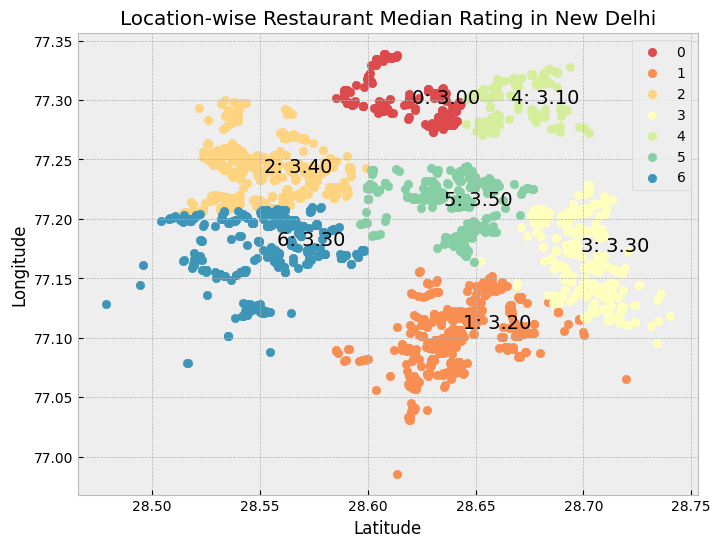

In [ ]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# KMeans clustering
kmeans = KMeans(n_clusters=7, random_state=0).fit(
    res_data[['Longitude', 'Latitude']]
)

res_data['pos'] = kmeans.labels_

# Calculate cluster centers and median ratings
pop_local = (
    res_data.groupby('pos')[['Longitude', 'Latitude', 'Aggregate rating']]
    .agg({
        'Longitude': np.mean,
        'Latitude': np.mean,
        'Aggregate rating': np.median
    })
    .reset_index()
)

# Plot
with plt.style.context('bmh'):
    pal = sns.color_palette('Spectral', 7)

    plt.figure(figsize=(8, 6))

    for i in range(7):
        ix = res_data['pos'] == i

        plt.scatter(
            res_data.loc[ix, 'Latitude'],
            res_data.loc[ix, 'Longitude'],
            color=pal[i],
            label=str(i)
        )

        plt.text(
            pop_local.loc[i, 'Latitude'],
            pop_local.loc[i, 'Longitude'],
            f"{i}: {pop_local.loc[i, 'Aggregate rating']:.2f}",
            fontsize=14,
            color='black'
        )

    plt.title('Location-wise Restaurant Median Rating in New Delhi')
    plt.xlabel('Latitude')
    plt.ylabel('Longitude')
    plt.legend()
    plt.show()

Here we can see that Central Delhi has slight better restaurants than North or South Suburb areas of Delhi.

## Food Choices Dataset Analysis

In [ ]:
food_data = pd.read_csv('food_choices.csv')
food_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GPA                           123 non-null    object 
 1   Gender                        125 non-null    int64  
 2   breakfast                     125 non-null    int64  
 3   calories_chicken              125 non-null    int64  
 4   calories_day                  106 non-null    float64
 5   calories_scone                124 non-null    float64
 6   coffee                        125 non-null    int64  
 7   comfort_food                  124 non-null    object 
 8   comfort_food_reasons          123 non-null    object 
 9   comfort_food_reasons_coded    106 non-null    float64
 10  cook                          122 non-null    float64
 11  comfort_food_reasons_coded.1  125 non-null    int64  
 12  cuisine                       108 non-null    float64
 13  diet_

### What are some comfort food in various situations such as stress, boredom, hunger, happiness?

In [ ]:
food_data[['comfort_food_reasons', 'comfort_food']]

,comfort_food_reasons,comfort_food
0,we dont have comfort,none
1,"Stress, bored, anger","chocolate, chips, ice cream"
2,"stress, sadness","frozen yogurt, pizza, fast food"
3,Boredom,"Pizza, Mac and cheese, ice cream"
4,"Stress, boredom, cravings","Ice cream, chocolate, chips"
...,...,...
120,boredom and sadness,"wine. mac and cheese, pizza, ice cream"
121,Loneliness / Homesick / Sadness,Pizza / Wings / Cheesecake
122,sadness,"rice, potato, seaweed soup"
123,"happiness, they are some of my favorite foods","Mac n Cheese, Lasagna, Pizza"


In [ ]:
def search_comfort(mood):
    lemmatizer = WordNetLemmatizer()
    foodcount = {}
    for i in range(124):
        temp = [temps.strip().replace('.','').replace(',','').lower() for temps in str(food_data["comfort_food_reasons"][i]).split(' ') if temps.strip() not in stop ]
        if mood in temp:
            foodtemp = [lemmatizer.lemmatize(temps.strip().replace('.','').replace(',','').lower()) for temps in str(food_data["comfort_food"][i]).split(',') if temps.strip() not in stop ]
            for a in foodtemp:
                if a not in foodcount.keys():
                    foodcount[a] = 1
                else:
                    foodcount[a] += 1
    sorted_food = []
    sorted_food = sorted(foodcount, key=foodcount.get, reverse=True)
    return sorted_food


def find_my_comfort_food(mood):
    topn = []
    topn = search_comfort(mood) #function create dictionary only for particular mood
    print("3 Popular Comfort Foods in %s are:"%(mood))
    print(topn[0])
    print(topn[1])
    print(topn[2])

## Main Part of our Project: Suggesting Restaurants based on User Moods
##### Under Following Moods
* stress
* boredom
* depression/sadness
* hunger
* laziness
* cold weather
* happiness
* watching tv

### Finding Restaurants based on cuisines

In [ ]:
res_data[res_data.Cuisines.str.contains('pizza', case=False)].sort_values(by='Aggregate rating', ascending=False).head(3)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country,fusion_num,Rating category,pos
3658,18400736,Owl is Well,1,New Delhi,"Greater Kailash (GK) 1, New Delhi",Greater Kailash (GK) 1,"Greater Kailash (GK) 1, New Delhi",77.240703,28.541636,"Burger, American, Fast Food, Italian, Pizza",...,No,3,4.5,Dark Green,Excellent,162,India,5,4,2
4665,18419910,Civil House,1,New Delhi,"26, Khan Market, New Delhi",Khan Market,"Khan Market, New Delhi",77.227358,28.600257,"European, Continental, Pizza",...,No,3,4.2,Green,Very Good,113,India,3,4,5
3111,18294269,Smoke On Water,1,New Delhi,"D-26, Connaught Place, New Delhi",Connaught Place,"Connaught Place, New Delhi",77.221544,28.633643,"Continental, Mexican, Burger, American, Pizza,...",...,No,3,4.1,Green,Very Good,467,India,6,4,5
